# Can a decision model find where an agent failed?

This notebook goes with the [post of the same name](https://vlrmzz.github.io/writing/jev-agent-failures.html).

When an AI agent fails a task, a person must read the run and find the step where it went wrong. This experiment
tests Jev, a decision model from TypeSafe, on that job: 257 failed agent runs that people labelled by hand.

This notebook shows the saved results as tables and charts. It does **not** call Jev, so you do not need an API key.
The scripts that made the results are in this folder, and `README.md` tells you how to run them.

In [1]:
# Run this cell first. On Colab it gets the repository. On your own machine it does nothing.
import os, sys
if "google.colab" in sys.modules and not os.path.exists("figures.py"):
    !git clone -q https://github.com/vlrmzz/ai-claims-experiments
    %cd ai-claims-experiments/agent-trace-failures

## 1. Jev against the human labels

Four sets of failed runs, each labelled by people with the step where the run went wrong.

- `exact`: Jev names the same step as the person.
- `top 3`: the person's step is among Jev's three most probable steps.
- `chance`: how often a random guess would be exact.
- `cut`: runs that were too long for Jev and were shortened to fit.

In [2]:
import json, pathlib

gt = json.load(open("ground_truth_results.json"))
print(f"{'dataset':20s}{'runs':>6s}{'cut':>6s}{'exact':>8s}{'top 3':>8s}{'chance':>8s}")
for name, d in gt.items():
    if not isinstance(d, dict) or "runs" not in d:
        continue
    print(f"{name:20s}{d['runs']:>6d}{d['runs_cut_to_fit']:>6d}{d['step_exact']:>8.0%}{d['step_in_top_3']:>8.0%}{d['step_chance']:>8.0%}")

dataset               runs   cut   exact   top 3  chance
agentrx_tau             29     0     41%     52%      3%
agentrx_magentic        44    14     18%     32%      5%
whowhen_hand            58    18     21%     31%      4%
whowhen_auto           126     1     50%     84%     12%


## 2. Jev against a frontier model

Half of the runs were kept apart as a test set (130 runs). On those, Claude read each full run and gave its own
answer. The chart shows how often each model names the same step as the person.

wrote _out/agent-trace-failures-step.png


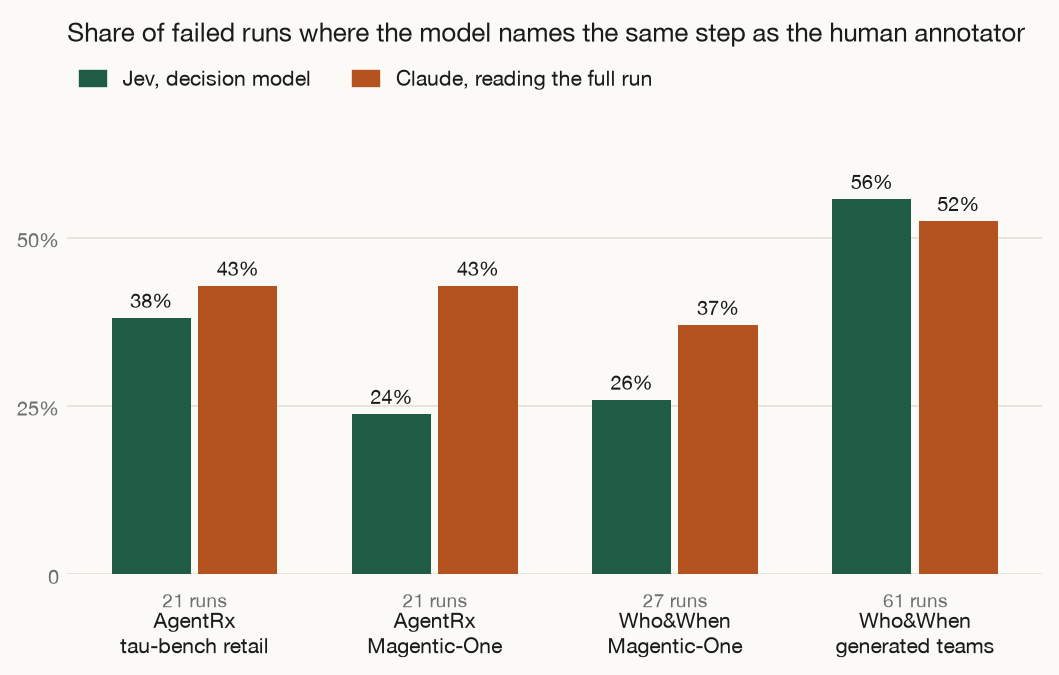

In [3]:
import figures
from IPython.display import Image

figures.OUT = pathlib.Path("_out")
figures.fig_step()
Image("_out/agent-trace-failures-step.png", width=720)

## 3. Does each model know when it is unsure?

Each model also says how sure it is. The chart groups the answers by that confidence and shows how many in each
group were right. If the bars rise from left to right, the confidence tells you which answers to trust.

wrote _out/agent-trace-failures-confidence.png


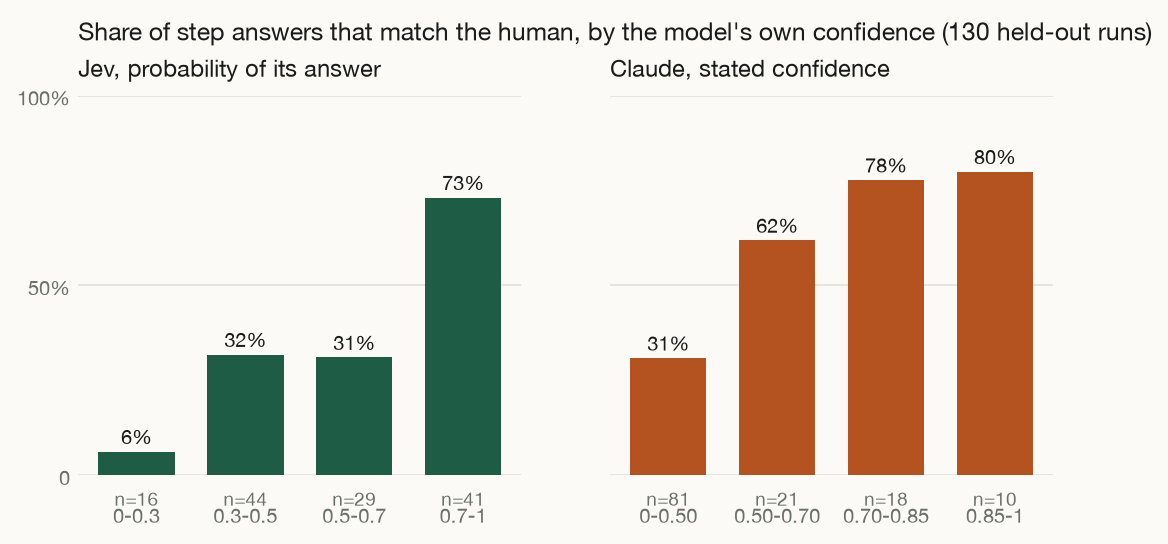

In [4]:
figures.fig_confidence()
Image("_out/agent-trace-failures-confidence.png", width=720)

## 4. A second use: kinds of failure

159 failed runs of GPT-5 on tau2-bench were read and sorted into 8 kinds of failure. The labels came from a model,
not from people, and nobody checked them by hand. The chart shows the 8 kinds and whose fault each failure was.

wrote _out/agent-trace-failures-patterns.png


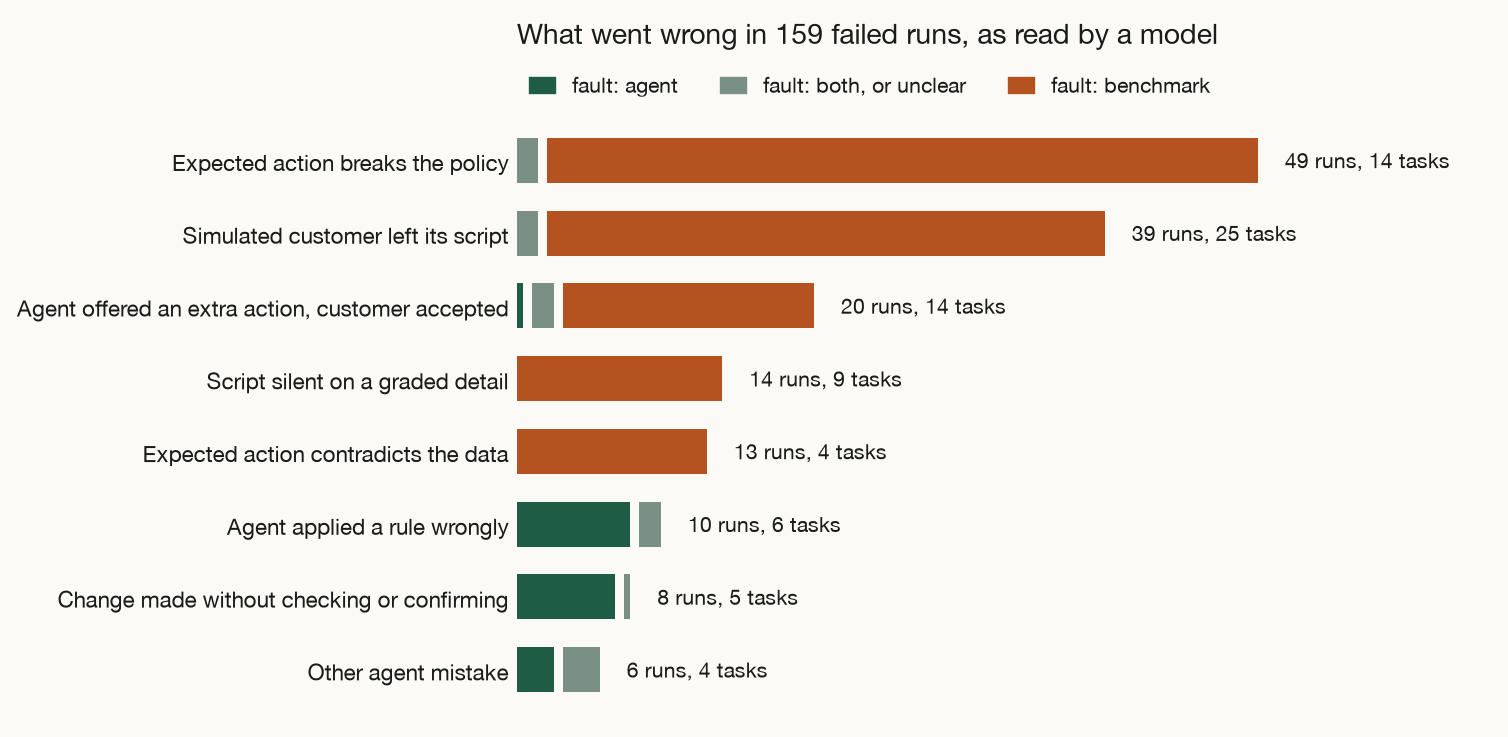

In [5]:
figures.fig_patterns()
Image("_out/agent-trace-failures-patterns.png", width=720)

## What this notebook does not do

- It does not call Jev. That needs a TypeSafe API key (`jev_ground_truth.py`, `jev_tune.py`, `jev_score.py`).
- It does not download the runs. `fetch.py` and `fetch_annotated.py` do that (38 MB in total).
- It does not draw the fourth figure of the post, because that figure needs the downloaded runs.

`README.md` gives the full order of the commands.